# 📊 RecycleVision — Exploratory Data Analysis (EDA)
**Project:** Garbage Image Classification Using Deep Learning  
**Notebook:** 01_EDA.ipynb  
**Goal:** Understand the dataset before preprocessing and model training

## 🔲 Cell 1 — Import Libraries

In [2]:
# Cell 1 - Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 🔲 Cell 2 — Set Dataset Path

In [3]:
# Cell 2 - Set Dataset Path
DATASET_PATH = r"D:\RecycleVision\data\raw\Garbage classification"

# Get all class names
classes = sorted(os.listdir(DATASET_PATH))
print('📂 Classes found:', classes)
print('📊 Total classes:', len(classes))

📂 Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
📊 Total classes: 6


## 🔲 Cell 3 — Count Images Per Class

In [4]:
# Cell 3 - Count Images Per Class
class_counts = {}

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(images)

# Display as table
df_counts = pd.DataFrame({
    'Class': list(class_counts.keys()),
    'Count': list(class_counts.values())
})
df_counts['Percentage'] = (df_counts['Count'] /
                           df_counts['Count'].sum() * 100).round(2)
df_counts = df_counts.sort_values('Count', ascending=False).reset_index(drop=True)

print('=' * 40)
print(df_counts.to_string(index=False))
print('=' * 40)
print(f'Total Images: {df_counts["Count"].sum()}')

    Class  Count  Percentage
    paper    594       23.51
    glass    501       19.83
  plastic    482       19.07
    metal    410       16.22
cardboard    403       15.95
    trash    137        5.42
Total Images: 2527


## 🔲 Cell 4 — Bar Chart (Class Distribution)

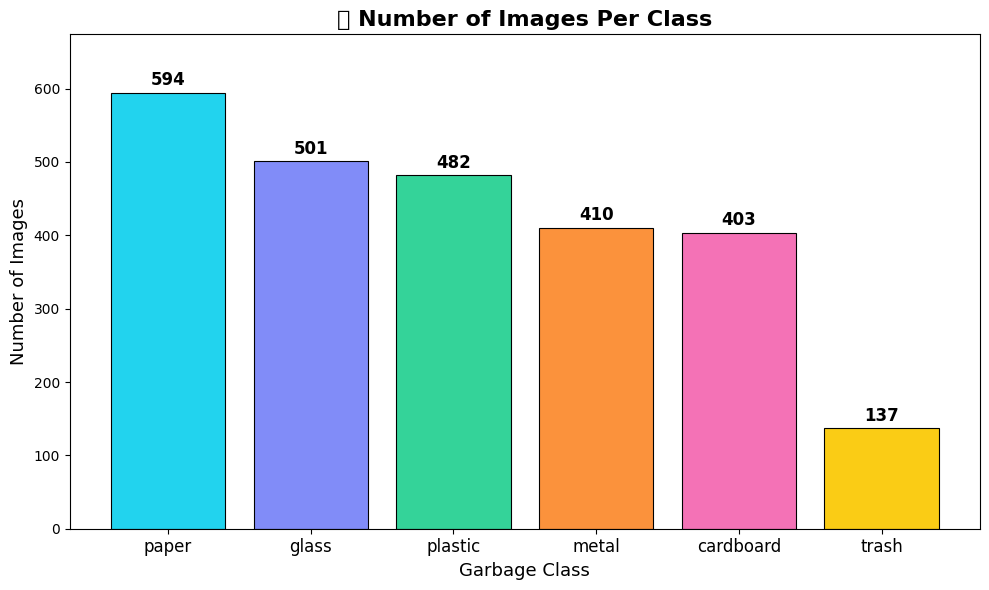

✅ Class distribution chart saved!


In [5]:
# Cell 4 - Visualize Class Distribution
plt.figure(figsize=(10, 6))
colors = ['#22d3ee', '#818cf8', '#34d399', '#fb923c', '#f472b6', '#facc15']

bars = plt.bar(df_counts['Class'], df_counts['Count'],
               color=colors, edgecolor='black', linewidth=0.8)

# Add count labels on bars
for bar, count in zip(bars, df_counts['Count']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(count), ha='center', va='bottom',
             fontweight='bold', fontsize=12)

plt.title('📊 Number of Images Per Class', fontsize=16, fontweight='bold')
plt.xlabel('Garbage Class', fontsize=13)
plt.ylabel('Number of Images', fontsize=13)
plt.xticks(fontsize=12)
plt.ylim(0, max(df_counts['Count']) + 80)
plt.tight_layout()
plt.savefig(r'D:\RecycleVision\data\class_distribution.png', dpi=150)
plt.show()
print('✅ Class distribution chart saved!')

## 🔲 Cell 5 — Pie Chart

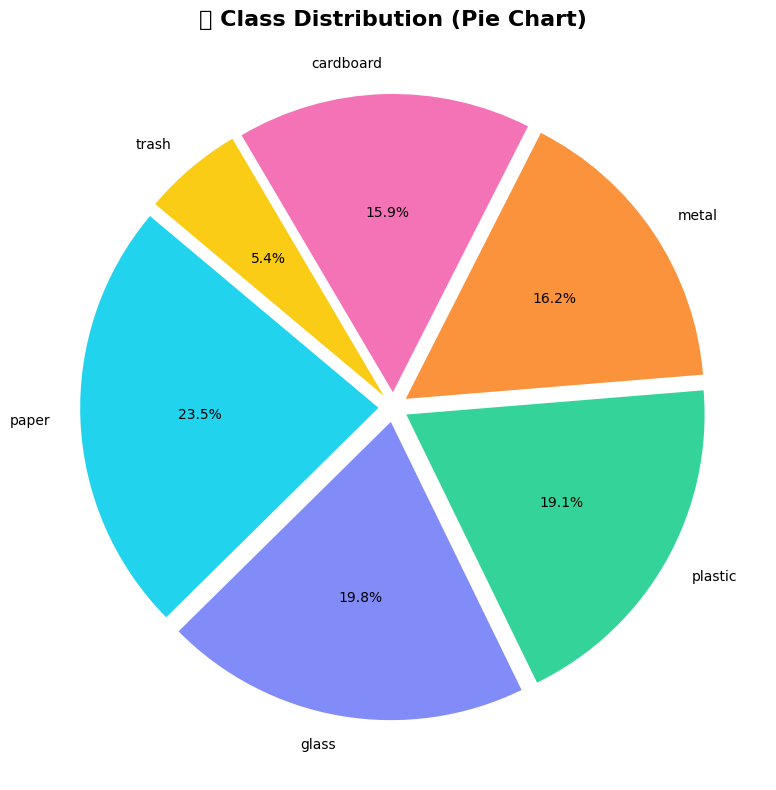

✅ Pie chart saved!


In [6]:
# Cell 5 - Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(df_counts['Count'],
        labels=df_counts['Class'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=140,
        explode=[0.05]*len(df_counts))

plt.title('🥧 Class Distribution (Pie Chart)',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\RecycleVision\data\class_pie_chart.png', dpi=150)
plt.show()
print('✅ Pie chart saved!')

## 🔲 Cell 6 — Sample Images from Each Class

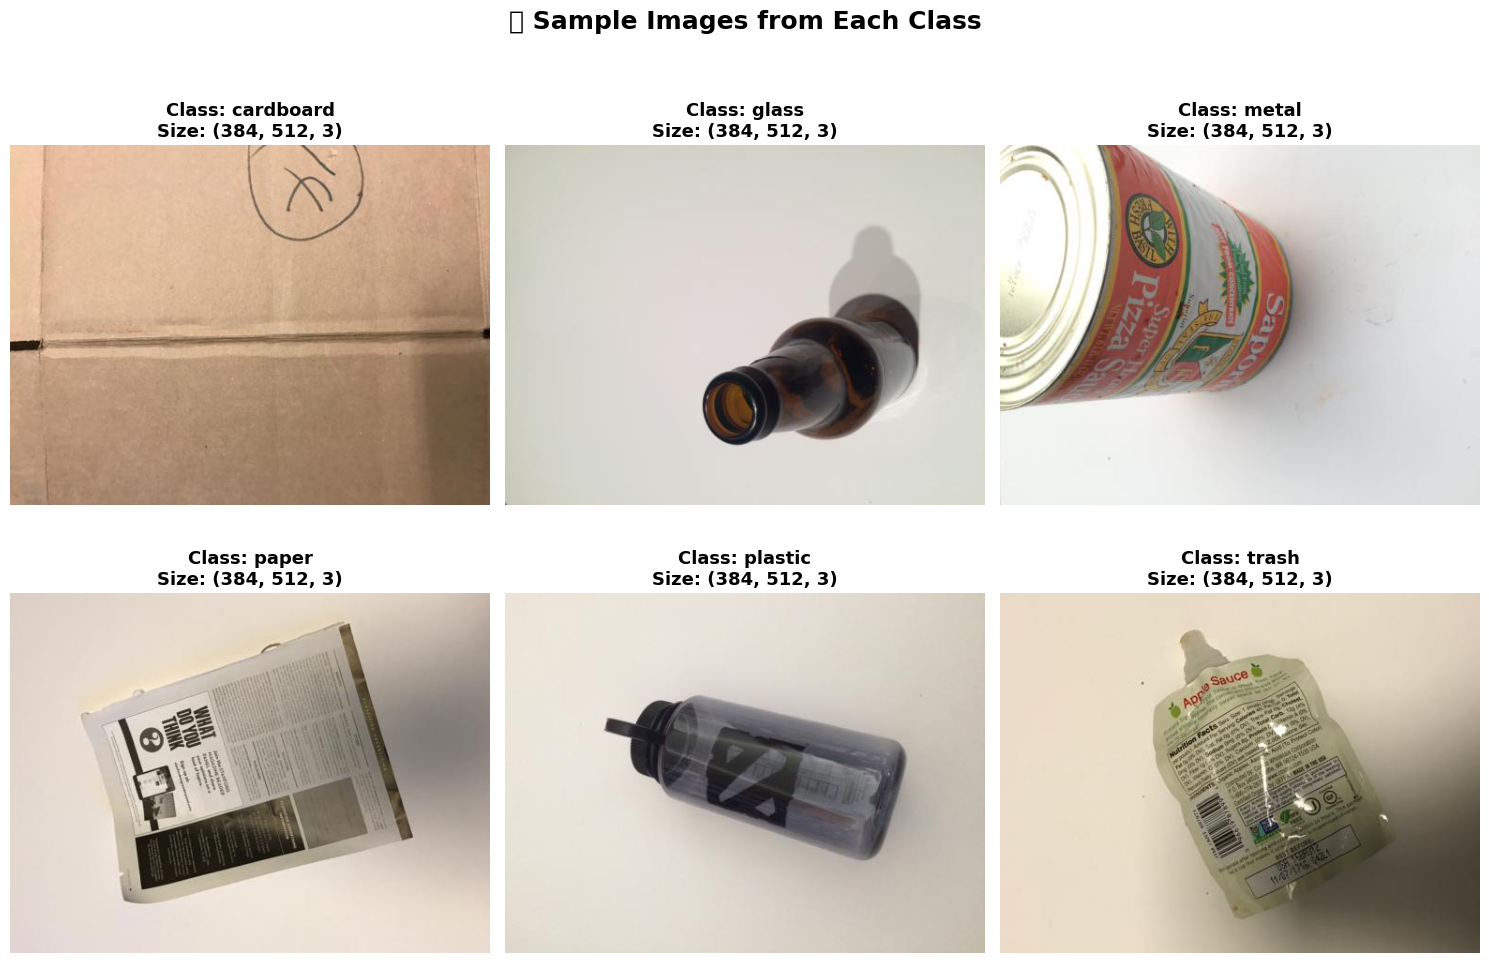

✅ Sample images saved!


In [7]:
# Cell 6 - Sample Images from Each Class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = os.listdir(cls_path)
    sample_img_path = os.path.join(cls_path, images[0])

    img = mpimg.imread(sample_img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f'Class: {cls}\nSize: {img.shape}',
                        fontsize=13, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('🖼️ Sample Images from Each Class',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'D:\RecycleVision\data\sample_images.png', dpi=150)
plt.show()
print('✅ Sample images saved!')

## 🔲 Cell 7 — Image Size Analysis

📐 Width  — Min: 512, Max: 512, Mean: 512
📐 Height — Min: 384, Max: 384, Mean: 384


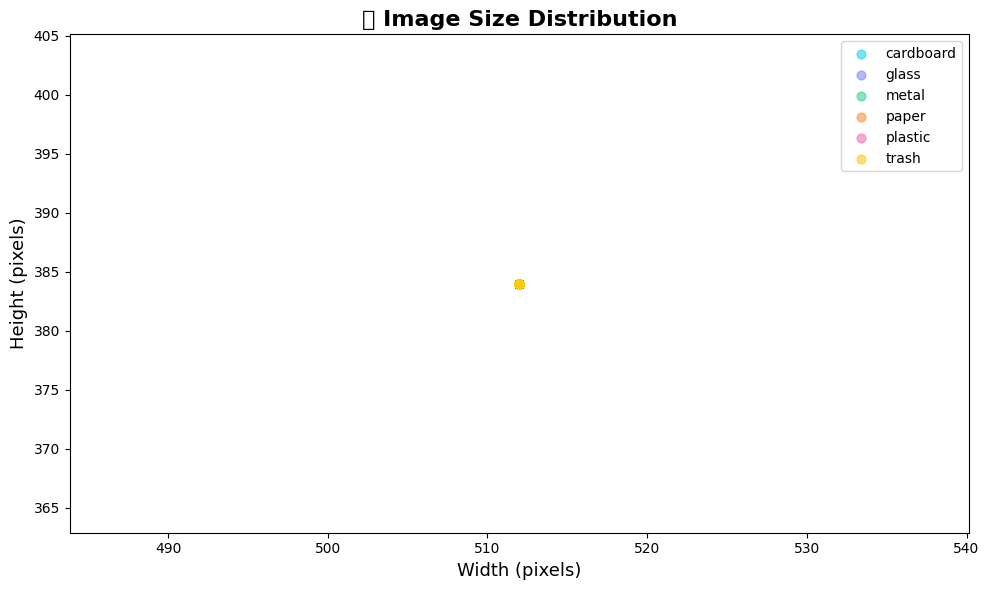

✅ Image size analysis saved!


In [8]:
# Cell 7 - Image Size Analysis
widths, heights, class_labels = [], [], []

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    for img_file in os.listdir(cls_path)[:50]:  # sample 50 per class
        img_path = os.path.join(cls_path, img_file)
        try:
            img = Image.open(img_path)
            w, h = img.size
            widths.append(w)
            heights.append(h)
            class_labels.append(cls)
        except:
            pass

print(f'📐 Width  — Min: {min(widths)}, Max: {max(widths)}, Mean: {int(np.mean(widths))}')
print(f'📐 Height — Min: {min(heights)}, Max: {max(heights)}, Mean: {int(np.mean(heights))}')

# Scatter plot of image sizes
plt.figure(figsize=(10, 6))
for i, cls in enumerate(classes):
    idx = [j for j, l in enumerate(class_labels) if l == cls]
    plt.scatter([widths[j] for j in idx],
                [heights[j] for j in idx],
                label=cls, alpha=0.6, color=colors[i], s=40)

plt.xlabel('Width (pixels)', fontsize=13)
plt.ylabel('Height (pixels)', fontsize=13)
plt.title('📐 Image Size Distribution', fontsize=16, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(r'D:\RecycleVision\data\image_sizes.png', dpi=150)
plt.show()
print('✅ Image size analysis saved!')

## 🔲 Cell 8 — Pixel Intensity Analysis

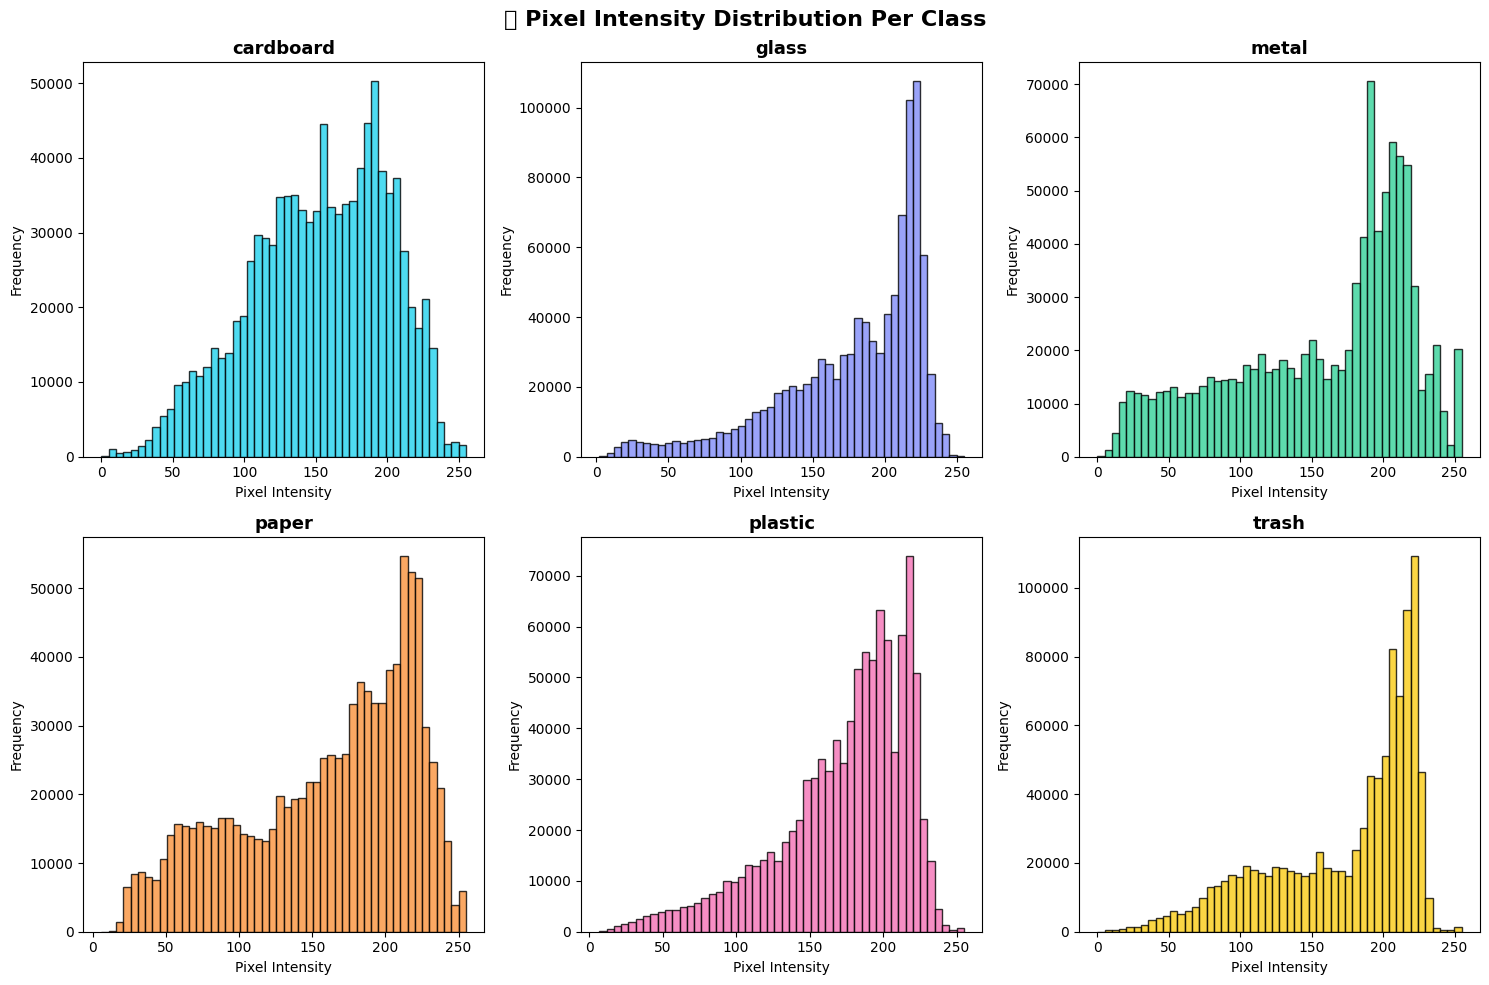

✅ Pixel intensity chart saved!


In [9]:
# Cell 8 - Pixel Intensity Distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = os.listdir(cls_path)

    all_pixels = []
    for img_file in images[:20]:  # sample 20 images per class
        img_path = os.path.join(cls_path, img_file)
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (224, 224))
            all_pixels.extend(img.flatten().tolist())
        except:
            pass

    axes[idx].hist(all_pixels, bins=50,
                   color=colors[idx], alpha=0.8, edgecolor='black')
    axes[idx].set_title(f'{cls}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Pixel Intensity')
    axes[idx].set_ylabel('Frequency')

plt.suptitle('🎨 Pixel Intensity Distribution Per Class',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\RecycleVision\data\pixel_intensity.png', dpi=150)
plt.show()
print('✅ Pixel intensity chart saved!')

## 🔲 Cell 9 — Class Imbalance Check

In [10]:
# Cell 9 - Class Imbalance Check
max_count = df_counts['Count'].max()
min_count = df_counts['Count'].min()
imbalance_ratio = round(max_count / min_count, 2)

print('=' * 45)
print('       CLASS IMBALANCE ANALYSIS')
print('=' * 45)
print(f'Most images  : {df_counts.iloc[0]["Class"]} ({max_count})')
print(f'Least images : {df_counts.iloc[-1]["Class"]} ({min_count})')
print(f'Imbalance ratio : {imbalance_ratio}x')
print('=' * 45)

if imbalance_ratio > 3:
    print('⚠️  HIGH IMBALANCE — Need to handle with augmentation')
elif imbalance_ratio > 1.5:
    print('⚠️  MODERATE IMBALANCE — Augmentation recommended')
else:
    print('✅ BALANCED dataset — No major action needed')

       CLASS IMBALANCE ANALYSIS
Most images  : paper (594)
Least images : trash (137)
Imbalance ratio : 4.34x
⚠️  HIGH IMBALANCE — Need to handle with augmentation


## 🔲 Cell 10 — EDA Summary Report

In [11]:
# Cell 10 - Final EDA Summary
print('=' * 50)
print('         📊 EDA SUMMARY REPORT')
print('=' * 50)
print(f'✅ Total Images       : {df_counts["Count"].sum()}')
print(f'✅ Total Classes      : {len(classes)}')
print(f'✅ Classes            : {", ".join(classes)}')
print(f'✅ Largest Class      : {df_counts.iloc[0]["Class"]} ({max_count} images)')
print(f'✅ Smallest Class     : {df_counts.iloc[-1]["Class"]} ({min_count} images)')
print(f'✅ Imbalance Ratio    : {imbalance_ratio}x')
print(f'✅ Avg Image Width    : {int(np.mean(widths))}px')
print(f'✅ Avg Image Height   : {int(np.mean(heights))}px')
print('=' * 50)
print('🔜 Next Step: Preprocessing & Augmentation')
print('=' * 50)

         📊 EDA SUMMARY REPORT
✅ Total Images       : 2527
✅ Total Classes      : 6
✅ Classes            : cardboard, glass, metal, paper, plastic, trash
✅ Largest Class      : paper (594 images)
✅ Smallest Class     : trash (137 images)
✅ Imbalance Ratio    : 4.34x
✅ Avg Image Width    : 512px
✅ Avg Image Height   : 384px
🔜 Next Step: Preprocessing & Augmentation
